# Mapping Post-Translational Modifications (PTMs) on KEAP1

This notebook explores the **biological and structural roles** of post-translational modifications (PTMs) on the KEAP1 protein. PTMs are chemical changes made to proteins after synthesis, and they play essential roles in regulating protein function, localization, and interactions.

In this notebook, we will:

- Retrieve curated PTMs from the `dbPTM` database, focusing on KEAP1. 
- Map PTMs to the **AlphaFold2-predicted 3D structure** of KEAP1. 
- Identify the ligand-binding site and calculate the **distance from each PTM to this region**. 
- Visualize PTMs in 3D to assess **which modifications may influence KEAP1 function or ligand binding**.

This structural mapping allows us to explore how **chemical regulation intersects with protein structure**, particularly in the context of cancer biology and oxidative stress response.

### Attribution

Part of this notebook adapts code from the [MMTF-Genomics](https://github.com/pwrose/mmtf-genomics) project developed by Dr. Peter Rose (RCSB PDB). The original work demonstrates how to map human genomic variants to 3D protein structures using Spark and G2S annotations.


In [1]:
import os
import py3Dmol
import ipywidgets as widgets
import pandas as pd
import requests
from Bio.PDB import PDBParser, PDBIO, Atom, Residue, Chain
from mmtfPyspark.datasets import g2sDataset, dbPtmDataset, pdbjMineDataset, pdbToUniProt
from io import StringIO
import numpy as np
from ipywidgets import Checkbox, HBox, Output
from IPython.display import display
from matplotlib import cm
import matplotlib.colors as mcolors

## Load Ligand Blacklist

Some ligands in PDB structures are not biologically meaningful; for example, water molecules, salts, or buffer components.

This code loads a custom blacklist of ligand codes (like `HOH`, `SO4`, etc.) so we can filter them out later and focus only on **relevant molecules**, such as inhibitors or cofactors.


In [2]:
# Load blacklist
blacklist_path = './blacklist_updated.txt'
blacklist = set()
if os.path.exists(blacklist_path):
    with open(blacklist_path, 'r') as f:
        for line in f:
            code = line.strip().split(',')[0]
            blacklist.add(code)

## Filter PDB Chain Containing the Ligand

A protein structure file (PDB) may contain multiple chains (e.g., A, B, C...) and not all of them interact with the ligand.

This function:
- Downloads the full PDB file
- Identifies which chain contains the specified ligand
- Filters the file to keep **only that chain**, so our visualizations are cleaner and easier to interpret


In [3]:
# Function to filter PDB chains and retain only the chain containing the ligand
def filter_chains(pdb_id, ligand_resname):
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    response = requests.get(url)
    
    if response.status_code == 200:
        pdb_lines = response.text.splitlines()
        filtered_lines = []
        chain_to_keep = None

        # Identify the chain that contains the ligand
        for line in pdb_lines:
            if line.startswith("HETATM") and ligand_resname in line:
                chain_to_keep = line[21]
                break

        if chain_to_keep is None:
            return None, None

        # Filter lines to include only the identified chain
        for line in pdb_lines:
            if (line.startswith("ATOM") or line.startswith("HETATM")) and line[21] == chain_to_keep:
                filtered_lines.append(line)
            elif line.startswith("TER") or line.startswith("ENDMDL"):
                filtered_lines.append(line)
            elif not (line.startswith("ATOM") or line.startswith("HETATM")):
                filtered_lines.append(line)

        filtered_pdb_content = '\n'.join(filtered_lines) + '\n'
        return filtered_pdb_content, chain_to_keep
    return None, None

## Detect Ligands in a PDB Structure

This function:
- Downloads the `.pdb` file
- Parses `HETNAM` lines (which describe ligands)
- Filters out blacklisted ligands
- Returns a list of meaningful ligand names found in the structure

These ligands are the candidates for calculating the binding site.



In [4]:
# Function to fetch and parse the PDB file to extract ligands, filtered by blacklist
def get_ligands_from_pdb(pdb_id):
    url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
    response = requests.get(url)
    
    if response.status_code == 200:
        pdb_file = response.text.split('\n')
        ligands = set()
        
        for line in pdb_file:
            if line.startswith("HETNAM"):
                parts = line.split()
                if len(parts) > 1:
                    lig = parts[1]
                    if lig not in blacklist and len(lig) > 1:
                        ligands.add(lig)
        
        return sorted(ligands) if ligands else ["No Ligand Found"]
    
    return ["No Ligand Found"]

## Load Variant Data and Create Structural Mapping IDs

This function loads your variant dataset and creates a unique identifier for each site in the format: 
`chr:g.positionREF>ALT` 
Example: `2:g.123456A>G`

This IDs are required by the **G2S dataset**, which maps genomic variants to 3D protein structures.


In [5]:
# Function to load mutation data and format mutation IDs
def load_variant_data(input_file):
    df = pd.read_csv(input_file)
    
    def var_id(chrom, pos, ref, alt):
        return str(chrom) + ":g." + str(pos) + ref + ">" + alt
    
    df['var_id'] = df.apply(lambda x: var_id(x['CHROM'], x['POS'], x['REF'], x['ALT']), axis=1)
    return df

## Visualize Protein and Ligand (with py3Dmol)

This function uses `py3Dmol` to display the structure of the protein and the ligand.

What it does:
- Loads the chain that contains the selected ligand
- Colors the protein as a light gray cartoon
- Colors the ligand in **red sticks**


In [6]:
# Function to visualize protein structure, ligand, and mapped mutations using py3Dmol
def visualize_protein(pdb_id, ligand_resname, mutations_df, show_ligand=True, show_labels=True, filtered_pdb=None):
    viewer = py3Dmol.view(width=800, height=600)
    viewer.setStyle({"cartoon": {"color": "lightgray"}})

    # Filter chains to retain only the one with the ligand
    filtered_pdb, chain_to_keep = filter_chains(pdb_id, ligand_resname)
    chain_info = f'Chain containing ligand: {chain_to_keep}' if chain_to_keep else 'No specific chain identified'
    print(chain_info)
    if filtered_pdb is not None and len(filtered_pdb.strip()) > 0:
        viewer.addModel(filtered_pdb, 'pdb')
        viewer.setStyle({"cartoon": {"color": "lightgray"}})
        viewer.zoomTo()
        print(f'Showing filtered chain: {chain_to_keep}')
        
        viewer.setStyle({"cartoon": {"color": "lightgray"}})
        print(f'Showing chain: {chain_to_keep}')

    # Style ligand
    if ligand_resname != "No Ligand Found" and show_ligand:
        viewer.setStyle({"resn": ligand_resname}, {"stick": {"colorscheme": "redCarbon"}})

    viewer.zoomTo()
    viewer.show()

## Update Ligand Options (Dropdown)

This function updates the list of available ligands whenever the PDB ID input changes.

Steps:
1. Get the PDB ID from the input widget
2. Call `get_ligands_from_pdb()` to retrieve all ligands
3. Update the dropdown widget with those ligand options


In [7]:
# Function to update ligand options when PDB ID changes
def update_ligand_options(change):
    pdb_id = pdb_id_widget.value
    ligands = get_ligands_from_pdb(pdb_id)
    ligand_resname_widget.options = ligands

## Update Visualization Panel

This function connects the widget settings (like checkboxes and dropdowns) to the actual 3D visualization.

- If the user clicks "Show structure" or changes a setting, this gets triggered.
- It reads the PDB ID, ligand, and toggle states from the widgets
- Then it calls `visualize_protein()` with those inputs to update the viewer


In [8]:
# Function to update visualization based on widget input
def update_visualization(change):
    show_ligand = show_ligand_widget.value
    with output_widget:
        output_widget.clear_output(wait=True)
        if ligand_resname_widget.value:
            visualize_protein(
                pdb_id_widget.value,
                ligand_resname_widget.value,
                mapped_pdbs,
                show_ligand=show_ligand,
            )

## Map Variant IDs to 3D Protein Structures with Spark + G2S

This function connects variant data (like `2:g.123456A>G`) to actual residue positions in 3D protein structures.

We use:

- **G2S Dataset**: Maps genomic variants to known PDB chains 
- **PDB→UniProt mappings**: Adds biological context to the structure 
- **Taxonomy filters**: Keeps only human proteins (ignores bacteria, etc.)

---

### Here is what it does:

1. **Query G2S** to retrieve structural matches for each variant 
2. **Filter for high sequence identity** (≥ 98%) to ensure accurate mappings 
3. **Keep only human proteins** using taxonomy metadata 
4. **Map structure residues to UniProt residues** (adds biological relevance) 
5. **Merge** it all into one DataFrame and save it as a CSV 

---

This gives us a fully annotated structural dataset of variants, residues, and the structures they land in.

In [9]:
# Adapted from Peter Rose's MMTF-Genomics project:
# https://github.com/pwrose/mmtf-genomics

import sys

# Ensure Spark uses the correct Python executable from the conda environment
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DUP2_PTMS") \
    .config("spark.driver.memory", "16G") \
    .config("spark.driver.maxResultSize", "8G") \
    .config("spark.executor.memory", "8G") \
    .getOrCreate()

def map_variants_to_structures(variant_df, output_file, spark):
    # variant IDs for G2S mapping
    variant_ids = variant_df['var_id'].tolist()

    # G2S annotations
    g2s_df = g2sDataset.get_full_dataset(variant_ids, ref_genome='hgvs-grch38').toPandas()

    # Filter by sequence identity to PDB sequence
    g2s_df['seqIdentity'] = g2s_df.identity/(g2s_df.seqTo - g2s_df.seqFrom + 1) * 100
    g2s_df = g2s_df[g2s_df.seqIdentity >= 98]
    
    # taxonomy data
    taxonomy_query = "SELECT * FROM sifts.pdb_chain_taxonomy WHERE scientific_name = 'Homo sapiens'"
    taxonomy_df = pdbjMineDataset.get_dataset(taxonomy_query).toPandas()
    
    # Join G2S and taxonomy
    enriched_df = g2s_df.merge(taxonomy_df, left_on=['structureId','chainId'], right_on=['pdbid','chain'], how='inner')
    enriched_df = enriched_df.drop(['pdbid','chain'], axis=1)  # remove redundant columns
    enriched_df['pdbPosition'] = enriched_df['pdbPosition'].astype('str') # must be string

    # PDB to UniProt mappings
    chains = set(enriched_df.structureChainId)
    up = pdbToUniProt.get_cached_residue_mappings().filter("pdbResNum IS NOT NULL").filter("uniprotNum IS NOT NULL")
    up_map = up.filter(up.structureChainId.isin(chains)).toPandas()
    up_map['uniprotNum'] = up_map.uniprotNum.astype('int') 

    # Join with UniProt data
    enriched_df = enriched_df.merge(up_map, left_on=['structureChainId','pdbPosition'], right_on=['structureChainId','pdbResNum'], how='left')

    # Convert to pandas DataFrame and save
    enriched_df = enriched_df.merge(variant_df, left_on='variationId', right_on='var_id', how='inner')
    enriched_df.fillna('', inplace=True)
    enriched_df.to_csv(output_file, index=False)
    
    return enriched_df

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/09 15:35:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/09 15:35:51 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Load and Map Variants to Protein Structures

In this step, we bring together everything we have built so far:

1. **Load the variant dataset** 
 This includes chromosome, position, reference and alternate base (e.g., `chr2:123456 A>G`)

2. **Map each variant to a 3D protein structure** 
 We use the `map_variants_to_structures()` function to find:
 - Which PDB structure it maps to 
 - What chain it appears in 
 - What the corresponding residue is 
 - How it connects to known UniProt annotations 

3. **Fill in missing data** (with `''`) 
 This avoids errors when plotting or merging with other tables later.

> By the end of this step, we will have a UniProt-annotated structural dataset based on genomic variants, ready for visualization and analysis.


In [10]:
# Load mutation data and map to structures
variant_data = load_variant_data("./KEAP1_mutations.csv")
mapped_pdbs = map_variants_to_structures(variant_data, "./KEAP1_mapped_structures.csv", spark)
mapped_pdbs.fillna('', inplace=True)

## Build Interactive Controls to Explore Structures

Now that we have structure mappings from variant data, you can explore them visually.

This block sets up:

- **Checkboxes** to toggle ligand display and PTM/centroid highlights 
- **Dropdowns** to select a PDB structure and a specific ligand 
- **An output panel** where the structure will be rendered 
- **Listeners** that update the visualization automatically when you change any setting 

> This makes the notebook feel like an interactive protein viewer; letting you explore structure–ligand relationships and post-translational modifications in 3D.


In [11]:
# Toggle widgets
show_ligand_widget = widgets.Checkbox(value=False, description='Show Ligand')

# Widget elements
pdb_ids = mapped_pdbs['structureId'].unique().tolist()
pdb_id_widget = widgets.Dropdown(options=pdb_ids, description='PDB ID:')
ligand_resname_widget = widgets.Dropdown(options=[], description='Ligand:')
output_widget = widgets.Output()

# Observe changes
show_ligand_widget.observe(update_visualization, names='value')
pdb_id_widget.observe(update_ligand_options, names='value')
ligand_resname_widget.observe(update_visualization, names='value')

# Display widgets
display(pdb_id_widget, ligand_resname_widget, show_ligand_widget, output_widget)

# Initial update calls (crucial step)
update_ligand_options(None)
update_visualization(None)

Dropdown(description='PDB ID:', options=('4L7B', '4IN4', '1U6D', '3VNH', '3VNG', '4IFJ', '1ZGK', '4XMB', '5X54…

Dropdown(description='Ligand:', options=(), value=None)

Checkbox(value=False, description='Show Ligand')

Output()

## Visualize High-Confidence AlphaFold Model

In this section, we use **AlphaFold**, a deep learning model that predicts protein structures, to visualize KEAP1 when no crystal structure is available.

However, not all residues are equally reliable. 
AlphaFold provides a **confidence score** (called the B-factor) for each atom. 
We only want to visualize **residues with high confidence** (typically ≥ 90).

Here is what we will do:

1. Download the predicted KEAP1 model from the [AlphaFold Protein Structure Database](https://alphafold.ebi.ac.uk)
2. Filter the structure to keep only **high-confidence residues**
3. Visualize the structure using `py3Dmol`

 This function:
- Parses each line of the PDB file
- Checks the **B-factor** (confidence score) for each atom
- Keeps only those atoms with a score ≥ 90
- Returns a filtered version of the structure

In [12]:
# Function to download and filter high-confidence protein model
def filter_high_confidence_residues(pdb_content, threshold=90):
    filtered_lines = []
    for line in pdb_content.splitlines():
        if line.startswith("ATOM") or line.startswith("HETATM"):
            try:
                b_factor = float(line[60:66].strip())
                if b_factor >= threshold:
                    filtered_lines.append(line)
            except ValueError:
                continue
        else:
            filtered_lines.append(line)
    return '\n'.join(filtered_lines) + '\n'

 This function:
- Takes a UniProt protein ID (like `Q14145` for KEAP1)
- Downloads its AlphaFold-predicted structure
- Saves it locally as a `.pdb` file


In [13]:
# Function to download high-confidence protein model
from pathlib import Path

def download_high_confidence_model(uniprot_id, out_dir=".", timeout=60):
    """
    Download the latest AlphaFold DB PDB for a UniProt accession.
    Returns the local filepath or None.
    """
    api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    headers = {"User-Agent": "Mozilla/5.0"}  # helps on some hosted platforms

    try:
        r = requests.get(api_url, headers=headers, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        if not data:
            print(f"No AlphaFold DB entry found for {uniprot_id}.")
            return None

        # Prefer the F1 entry if present
        entry = next((e for e in data if e.get("entryId", "").endswith("-F1")), data[0])

        pdb_url = entry.get("pdbUrl")
        if not pdb_url:
            print(f"No pdbUrl available for {uniprot_id}.")
            return None

        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"{uniprot_id}_high_confidence.pdb"

        m = requests.get(pdb_url, headers=headers, timeout=timeout)
        m.raise_for_status()
        out_path.write_bytes(m.content)

        print(f"Downloaded {uniprot_id} from {pdb_url}")
        return str(out_path)

    except requests.RequestException as e:
        print(f"Failed to download model for {uniprot_id}: {e}")
        return None


 This is the main function triggered by the user.

It:
- Downloads the model
- Filters for confident regions
- Displays the 3D structure in **cyan**

> You can now visually compare AlphaFold predictions to experimental structures.

In [14]:
# Function to download and visualize high-confidence model
def download_and_visualize(change):
    with high_conf_output:
        high_conf_output.clear_output(wait=True)
        protein_id = protein_id_widget.value
        model_path = download_high_confidence_model(protein_id)
        if model_path:
            with open(model_path, 'r') as file:
                pdb_data = file.read()
            filtered_pdb_data = filter_high_confidence_residues(pdb_data)
            print("Filtered high-confidence residues applied.")
            viewer = py3Dmol.view(width=800, height=600)
            viewer.addModel(filtered_pdb_data, 'pdb')
            viewer.setStyle({"cartoon": {"color": "cyan"}})
            viewer.zoomTo()
            viewer.show()

## Interactive Widget: Load High-Confidence AlphaFold Model

This section sets up:
- A **text box** where the user can input a UniProt ID 
 (for KEAP1, this would be: `Q14145`)
- A **download button** that fetches the AlphaFold model for that protein
- An **output area** where the filtered, high-confidence structure will be visualized

> You can explore any protein supported by AlphaFold by entering its UniProt ID.

In [15]:
# High-confidence model widget
protein_id_widget = widgets.Text(value='', description='Uniprot ID:')  # value -> Q14145 for KEAP1 
download_button = widgets.Button(description='Download High-Confidence Model', layout=widgets.Layout(width='auto'))
high_conf_output = widgets.Output()

# Button action
download_button.on_click(download_and_visualize)

# Display Widget
display(protein_id_widget, download_button, high_conf_output)

Text(value='', description='Uniprot ID:')

Button(description='Download High-Confidence Model', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## Align Sequences: High-Confidence Model vs PDB Structure

Before we can map ligand positions from a PDB file to the AlphaFold model, we need to **align the sequences** of both structures.

This section includes multiple helper functions that together:
- Extract sequences from `.pdb` structures
- Divide them into overlapping fragments
- Match those fragments between the PDB and AlphaFold models
- Fill gaps in the alignment when needed
- Display a visual alignment with `|` for matching residues

By the end, we will have a **residue-residue alignment** between the PDB chain and the AlphaFold model.


 This helper function converts standard 3-letter amino acid codes (like `LYS`, `VAL`) to 1-letter codes (`K`, `V`), which are easier to align.


In [16]:
# Three-letter to one-letter amino acid conversion
def amino_acid_to_one_letter(three_letter_code):
    amino_acid_map = {
        'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
        'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
        'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
        'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
    }
    return amino_acid_map.get(three_letter_code, 'X')  # 'X' for unknown residues

 This function extracts:
- The **1-letter amino acid sequence**
- The **residue number positions** 
From either a PDB file or string.

It skips non-standard residues and gaps.

In [17]:
# Extract sequence and positions from PDB structure
def extract_sequence_with_positions(pdb_input):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('X', pdb_input if os.path.isfile(pdb_input) else StringIO(pdb_input))
    sequence, positions = [], []

    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0] == ' ':
                    residue_name = residue.get_resname()
                    one_letter_code = amino_acid_to_one_letter(residue_name)
                    sequence.append(one_letter_code)
                    positions.append(residue.get_id()[1])

    return ''.join(sequence), positions

 This function breaks the PDB sequence into overlapping fragments (e.g., windows of 10 amino acids with 8-residue overlap).

We will try to match each of these fragments in the AlphaFold model.


In [18]:
# Divide sequence into overlapping groups
def divide_sequence(seq, positions, group_size, overlap):
    groups = []
    for i in range(0, len(seq) - group_size + 1, group_size - overlap):
        group = seq[i:i + group_size]
        pos = positions[i:i + group_size]
        groups.append((group, pos[0], pos[-1]))
    return groups

 This function compares each fragment against the high-confidence model and returns a match if the identity is ≥ 99%.

It gives us the residue range of that fragment in both sequences.


In [19]:
# Check group matches in high-confidence sequence
def check_group_in_sequence(main_seq, main_positions, group, threshold):
    for i in range(len(main_seq) - len(group) + 1):
        sub_seq = main_seq[i:i + len(group)]
        match_ratio = sum(a == b for a, b in zip(sub_seq, group)) / len(group)
        if match_ratio >= threshold:
            return True, main_positions[i], main_positions[i + len(group) - 1]
    return False, None, None

 If there are missing residues in the alignment, this function tries to fill them based on known positions in the PDB dictionary.

This ensures continuity and more complete mapping.


In [22]:
# Fill gaps using known positions
def fill_gaps_using_other_dict(df, other_dict):
    # Find the first index with valid match
    start_idx = None
    for i, (seq, amin) in enumerate(zip(df['other_seq'], df['other_amin'])):
        if seq != '-' and amin != '-':
            start_idx = i
            break

    if start_idx is None:
        return df  # No valid matches found

    # Get corresponding starting position in the other_dict
    start_pos = int(df.at[start_idx, 'other_seq'])

    if start_pos not in other_dict:
        return df

    # Fill downstream positions linearly, only if gaps and still matches other_dict
    dict_positions = sorted(other_dict.keys())
    try:
        dict_start_idx = dict_positions.index(start_pos)
    except ValueError:
        return df

    for i, pos in enumerate(dict_positions[dict_start_idx:], start=start_idx):
        if i >= len(df):
            break
        if df.at[i, 'other_seq'] == '-' and df.at[i, 'other_amin'] == '-':
            df.at[i, 'other_seq'] = pos
            df.at[i, 'other_amin'] = other_dict[pos]
        else:
            # Stop when the next available position mismatches what’s already there
            if str(df.at[i, 'other_seq']) != str(pos):
                break

    return df

 Prints a classic sequence alignment:
- Top line = AlphaFold sequence
- Middle = `|` for matches
- Bottom = PDB chain sequence

This helps you *see* where the sequences agree or diverge.


In [21]:
def display_text_alignment(df, line_length=80):
    aligned_seq1 = []
    aligned_seq2 = []
    match_line = []

    for _, row in df.iterrows():
        aa1 = row['high_amin']
        aa2 = row['other_amin']

        aligned_seq1.append(aa1)
        aligned_seq2.append(aa2)
        match_line.append('|' if aa1 == aa2 and aa1 != '-' else ' ')

    # Chunk and print in blocks
    for i in range(0, len(aligned_seq1), line_length):
        seq1_chunk = ''.join(aligned_seq1[i:i+line_length])
        match_chunk = ''.join(match_line[i:i+line_length])
        seq2_chunk = ''.join(aligned_seq2[i:i+line_length])

        print(seq1_chunk)
        print(match_chunk)
        print(seq2_chunk)
        print()

 This function ties everything together:

- Gets the sequences from AlphaFold and the selected PDB
- Splits and matches fragments
- Builds a position-by-position alignment table
- Displays it visually and computes a match score (in %)
- Stores the result in `latest_alignment_df` for downstream use

> This alignment is what allows us to "transfer" ligand positions from one structure onto the AlphaFold model.


In [20]:
# Updated Widget action function 
def perform_alignment(change):
    with alignment_output:
        alignment_output.clear_output(wait=True)

        protein_id = protein_id_widget.value
        model_path = f'./{protein_id}_high_confidence.pdb'

      
        with open(model_path, 'r') as f:
            high_conf_raw = f.read()
        filtered_high_conf_pdb = filter_high_confidence_residues(high_conf_raw)

        high_confidence_seq, high_confidence_positions = extract_sequence_with_positions(filtered_high_conf_pdb)

        pdb_id = seq2_widget.value
        filtered_pdb, _ = filter_chains(pdb_id, ligand_resname_widget.value)

        if filtered_pdb:
            other_seq, other_positions = extract_sequence_with_positions(filtered_pdb)

            # Divide the other sequence into overlapping groups
            groups = divide_sequence(other_seq, other_positions, group_size=10, overlap=8)

            # Find matches for each group in the high confidence sequence
            matches = []
            for group, start, end in groups:
                match, match_start, match_end = check_group_in_sequence(
                    high_confidence_seq, high_confidence_positions, group, threshold=0.99)
                if match:
                    matches.append((group, start, end, match_start, match_end))

            # Create dictionaries for fast lookup
            high_conf_dict = dict(zip(high_confidence_positions, high_confidence_seq))
            other_dict = dict(zip(other_positions, other_seq))

            # Create a table with all positions in the high confidence sequence
            data = {'high_seq': [], 'high_amin': [], 'other_seq': [], 'other_amin': []}
            coincidences = 0

            for high_seq_pos in range(high_confidence_positions[0], high_confidence_positions[-1] + 1):
                high_amin = high_conf_dict.get(high_seq_pos, '-')

                match_found = False
                for group, other_start, other_end, match_start, match_end in matches:
                    if match_start <= high_seq_pos <= match_end:
                        other_seq_pos = other_start + (high_seq_pos - match_start)
                        other_amin = other_dict.get(other_seq_pos, '-')
                        if high_amin == other_amin:
                            coincidences += 1
                        data['high_seq'].append(high_seq_pos)
                        data['high_amin'].append(high_amin)
                        data['other_seq'].append(other_seq_pos)
                        data['other_amin'].append(other_amin)
                        match_found = True
                        break

                if not match_found:
                    data['high_seq'].append(high_seq_pos)
                    data['high_amin'].append(high_amin)
                    data['other_seq'].append('-')
                    data['other_amin'].append('-')

            df = pd.DataFrame(data)

            # Fill alignment gaps
            df = fill_gaps_using_other_dict(df, other_dict)

            # Display alignment
            display_text_alignment(df)

            score = (df['high_amin'] == df['other_amin']).sum() / len(df) * 100
            print(f'Score={score:.1f}')

            # Store result globally
            global latest_alignment_df
            latest_alignment_df = df
        else:
            print('Error: Unable to extract sequence from selected PDB.')

## Interactive Sequence Alignment Panel

To compare the high-confidence model with one of the available PDB structures, we create an interactive widget interface.

This panel includes:
- A label that shows we are aligning against the high-confidence AlphaFold model
- A **dropdown menu** to select one of the PDB IDs that has mapped mutations
- An **"Align Sequences"** button to trigger the alignment process
- An output area to display the results and alignment score

> After running the alignment, you will see a text-based comparison of the sequences, and a score that reflects how well they match.


In [23]:
# Alignment widget
seq1_widget = widgets.Label(value='Sequence from High-Confidence Structure')
seq2_widget = widgets.Dropdown(options=pdb_ids, description='PDB Sequence:')
align_button = widgets.Button(description='Align Sequences', layout=widgets.Layout(width='auto'))
alignment_output = widgets.Output()

# Button action
align_button.on_click(perform_alignment)

display(seq1_widget, seq2_widget, align_button, alignment_output)

Label(value='Sequence from High-Confidence Structure')

Dropdown(description='PDB Sequence:', options=('4L7B', '4IN4', '1U6D', '3VNH', '3VNG', '4IFJ', '1ZGK', '4XMB',…

Button(description='Align Sequences', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## Structural Alignment: PDB → AlphaFold

We now perform a **3D alignment** between:
- The AlphaFold high-confidence model (reference structure)
- The selected PDB file containing a ligand (source structure)

This is necessary because even if both structures describe the same protein, their **coordinates and orientations differ**.

Here is how the process works:

1. **Find matching residues** in both structures based on the sequence alignment 
2. **Extract coordinates** for each pair of matching residues 
3. **Apply Kabsch algorithm** to superimpose the structures 
4. **Transform** the ligand-containing PDB structure to match the AlphaFold model 
5. **Visualize all models** to confirm the alignment and see how well they match

This allows us to later compute distances **in the AlphaFold reference frame**, even if the ligand came from a different PDB.

In [24]:
# Global viewer
viewer = None

def make_seq_map(structure, only_chains=None):
    mapping = {}
    for chain in structure[0]:
        if only_chains and chain.id not in only_chains:
            continue
        for res in chain:
            if 'CA' in res:
                seq_id = res.get_id()[1]
                mapping[seq_id] = res
    return mapping

def structure_to_pdbblock(structure):
    io = PDBIO()
    io.set_structure(structure)
    out = StringIO()
    io.save(out)
    return out.getvalue()

## What is the Kabsch Algorithm?

The **Kabsch algorithm** is used to find the best rotation matrix that aligns two sets of points in 3D space.

In our case:
- One set of points is from the **AlphaFold high-confidence model**
- The other is from the **ligand-containing PDB structure**

We want to:
- Superimpose the PDB structure onto the AlphaFold model
- **Minimize the RMSD** (root-mean-square deviation) between matching residues

### Why is this useful?

Even if two structures describe the *same protein*, their coordinates may differ due to:
- Different crystallization conditions
- Different conformations
- Random orientations from structure prediction software

The Kabsch algorithm corrects for this by:
- Translating both point sets to their centroids (centering them)
- Computing the optimal rotation matrix using **singular value decomposition (SVD)**
- Applying the rotation + translation to align the structures

This ensures:
> The ligand and mutations are **placed accurately** in the high-confidence AlphaFold frame — allowing us to measure real distances like mutation-to-ligand centroid.

### Mathematical Overview

Given two sets of points `P` (from the PDB) and `Q` (from AlphaFold):
1. Subtract their centroids → `P'`, `Q'`
2. Compute the **covariance matrix**: `C = P'.T @ Q'`
3. Apply **SVD**: `C = V @ S @ W.T`
4. Get the **rotation matrix**: `R = V @ D @ W.T` (where `D` corrects for handedness)
5. Align by: `P_aligned = P' @ R + centroid(Q)`

### In our code:
We apply the rotation and translation to **every atom** in the PDB file, including the ligand.

> This lets us treat all subsequent 3D measurements as if they happened in the AlphaFold reference space.



 This is the core of the structural alignment process:

- Loads and parses the AlphaFold model and the PDB chain containing the ligand
- Matches coordinates using only **aligned, identical residues**
- Applies the **Kabsch algorithm** to compute the optimal rotation + translation
- Transforms the source PDB structure (including its ligand!) into the AlphaFold coordinate frame
- Renders a **4-model viewer**:
 - Cyan: Filtered AlphaFold model
 - Gray: Full high-confidence model
 - Blue: Aligned PDB chain
 - Black: Original (unaligned) PDB chain
- Highlights the ligand in **red sticks** to compare its location before and after alignment

> After running this function, we are ready to **analyze ligand proximity** using a consistent 3D coordinate space.



In [25]:
def align_structures_callback(change=None):
    global viewer
    with structure_view_output:
        structure_view_output.clear_output(wait=True)

        protein_id = protein_id_widget.value
        model_path = f'./{protein_id}_high_confidence.pdb'
        pdb_id = seq2_widget.value
        ligand_resname = ligand_resname_widget.value

        # Load and filter
        filtered_pdb, _ = filter_chains(pdb_id, ligand_resname)
        parser = PDBParser(QUIET=True)
        high_structure = parser.get_structure('high', model_path)
        other_structure = parser.get_structure('other', StringIO(filtered_pdb))
        original_other_structure = parser.get_structure('original', StringIO(filtered_pdb))

        # Identify aligned chains
        aligned_chains = set()
        for chain in other_structure[0]:
            if any(res.get_resname() == ligand_resname for res in chain):
                aligned_chains.add(chain.id)

        high_seq_map = make_seq_map(high_structure)
        other_seq_map = make_seq_map(other_structure, aligned_chains)

        # Get matching residues
        high_coords = []
        other_coords = []
        for _, row in latest_alignment_df.iterrows():
            if row['high_amin'] != '-' and row['other_amin'] != '-' and row['high_amin'] == row['other_amin']:
                high_seq = row['high_seq']
                other_seq = row['other_seq']
                if high_seq in high_seq_map and other_seq in other_seq_map:
                    high_coords.append(high_seq_map[high_seq]['CA'].get_coord())
                    other_coords.append(other_seq_map[other_seq]['CA'].get_coord())

        high_coords = np.array(high_coords)
        other_coords = np.array(other_coords)
        if len(high_coords) == 0 or len(other_coords) == 0:
            print("No matched residues found for alignment.")
            return

        # Kabsch alignment
        P = other_coords - np.mean(other_coords, axis=0)
        Q = high_coords - np.mean(high_coords, axis=0)
        C = np.dot(P.T, Q)
        V, S, W = np.linalg.svd(C)
        d = np.sign(np.linalg.det(np.dot(V, W)))
        D = np.eye(3); D[2,2] = d
        rotation = np.dot(np.dot(V, D), W)
        translation = np.mean(high_coords, axis=0) - np.dot(np.mean(other_coords, axis=0), rotation)

        # Transform all atoms (including ligand)
        for chain in other_structure[0]:
            for residue in chain:
                for atom in residue:
                    atom.transform(rotation, translation)

        # Prepare viewer models
        with open(model_path, 'r') as f:
            raw_high_conf_data = f.read()
        global filtered_high_conf_pdb
        filtered_high_conf_pdb = filter_high_confidence_residues(raw_high_conf_data)

        aligned_pdb = structure_to_pdbblock(other_structure)
        global aligned_structure
        aligned_structure = other_structure

        # Viewer rendering
        viewer = py3Dmol.view(width=800, height=600)
        viewer.addModel(filtered_high_conf_pdb, 'pdb')  # Model 0
        viewer.setStyle({'model': 0}, {'cartoon': {'color': 'cyan'}})

        viewer.addModel(structure_to_pdbblock(high_structure), 'pdb')  # Model 1
        viewer.setStyle({'model': 1}, {'cartoon': {'color': 'gray'}})

        viewer.addModel(aligned_pdb, 'pdb')  # Model 2
        viewer.setStyle({'model': 2}, {'cartoon': {'color': 'blue'}})

        viewer.addModel(structure_to_pdbblock(original_other_structure), 'pdb')  # Model 3
        viewer.setStyle({'model': 3}, {'cartoon': {'color': 'black'}})

        # Highlight ligand
        if ligand_resname_widget.value != "No Ligand Found":
            viewer.setStyle({'model': 2, 'resn': ligand_resname_widget.value}, {'stick': {'colorscheme': 'redCarbon'}})

        viewer.zoomTo()
        viewer.show()

        update_viewer()


## Visual Comparison of Aligned vs. Unaligned Structures

This panel lets you **interactively toggle** which models are visible in the viewer. 
It is one of the most important parts of the notebook; because now, you can **see for yourself why the alignment step was necessary**.

The checkboxes control:

- **High-Confidence Model** (cyan): AlphaFold2 structure, filtered for confident residues
- **Full High Structure** (gray): AlphaFold2 unfiltered (may include lower-confidence regions)
- **Aligned Structure** (blue): The ligand-containing PDB, after it was superimposed using the **Kabsch algorithm**
- **Unaligned Structure** (black): The same PDB file, but *before* alignment
- **Ligand** (red): The ligand itself, only visible in the aligned structure

---

### Why this is important:

By toggling between these views, you can directly compare:

- Where the original structure was
- Where it ends up after alignment
- Whether the transformation properly placed it inside the AlphaFold model

> This is a rare opportunity to **visually validate** a mathematical alignment method like the Kabsch algorithm.

Take a moment to:
- Turn off everything but the aligned model + ligand
- Toggle the unaligned structure on and off 
 You will likely see the structure shift positions; that is the power of alignment in action.



In [26]:
toggle_model0 = widgets.Checkbox(value=False, description='High-Confidence Model')
toggle_model1 = widgets.Checkbox(value=False, description='Full High Structure')
toggle_model2 = widgets.Checkbox(value=False, description='Aligned Structure')
toggle_model3 = widgets.Checkbox(value=False, description='Unaligned Structure')
toggle_ligand = widgets.Checkbox(value=False, description='Ligand')

def update_viewer(change=None):
    if viewer is None:
        return
    viewer.setStyle({'model': 0}, {'cartoon': {'color': 'cyan'}} if toggle_model0.value else {})
    viewer.setStyle({'model': 1}, {'cartoon': {'color': 'gray'}} if toggle_model1.value else {})
    viewer.setStyle({'model': 2}, {'cartoon': {'color': 'blue'}} if toggle_model2.value else {})
    viewer.setStyle({'model': 3}, {'cartoon': {'color': 'black'}} if toggle_model3.value else {})

    if toggle_ligand.value:
        viewer.addStyle(
            {'model': 2, 'resn': ligand_resname_widget.value},
            {'stick': {'colorscheme': 'redCarbon'}}
        )
    else:
        viewer.setStyle({'model': 2, 'resn': ligand_resname_widget.value}, {})

    viewer.update()

toggle_model0.observe(update_viewer, names='value')
toggle_model1.observe(update_viewer, names='value')
toggle_model2.observe(update_viewer, names='value')
toggle_model3.observe(update_viewer, names='value')
toggle_ligand.observe(update_viewer, names='value')

align_structures_button = widgets.Button(description="Align Structures", layout=widgets.Layout(width='auto'))
align_structures_button.on_click(align_structures_callback)

structure_view_output = widgets.Output()
display(align_structures_button, structure_view_output)
display(widgets.HBox([toggle_model0, toggle_model1, toggle_model2, toggle_model3, toggle_ligand]))


Button(description='Align Structures', layout=Layout(width='auto'), style=ButtonStyle())

Output()

## Visualizing the Ligand-Binding Site in 3D

Now that we have:
- Aligned the ligand-containing PDB to the AlphaFold model
- Verified the residue-level alignment
- Located the ligand in the aligned structure

...we can visualize the **entire binding environment** and interactively explore

### What is being shown?

- **Aligned Structure**: PDB model that originally contained the ligand 
- **High-Confidence Model**: AlphaFold structure, filtered for confident residues 
- **Ligand**: Rendered in red sticks 
- **Centroid**: Center of the ligand (approximate binding site center) 
- **Bounding Box**: Orange cube around the ligand's atoms 


### Why is this useful?

This visualization shows:
- Where the ligand binds
- Which residues (or PTMs) are nearby
- Whether PTMs fall *inside* the ligand's binding site

> This is what allows us to **classify PTMs by their proximity to functional regions**, which is a key insight in understanding structural disruption.


## Why Did We Create the Ligand Box?

You might be wondering: why not just use the ligand's position directly? 
Why go through the trouble of building a **3D bounding box** and calculating its **centroid**?

Here is why this step matters:

---

### A Ligand Is not Just One Point

Ligands are made of **many atoms**, and their position in 3D space is not represented by a single coordinate. To understand the **full space they occupy**, we calculate:

- A **bounding box**; the smallest rectangular volume that contains all the ligand's atoms
- A **centroid**; the center of the bounding box

This allows us to define a **single, representative coordinate** that describes:
- Where the ligand is located
- What region of the protein it interacts with

---

### Why This Is Useful

- It lets us compare ligands across different structures 
 (even if the ligands are rotated or shifted slightly)
- It allows us to measure **distances from PTMs** to a **standardized binding site**
- It gives us a concrete way to answer: 
 _"Is this PTM inside, near, or far from the ligand-binding site?"_

---

### Repercussions for Structural Analysis

The ligand box and centroid are critical because they:

- Define the **functional hotspot** of the protein
- Anchor all future calculations
- Enable comparisons between aligned structures and predictions

> Without this step, we could not compare PTMs or ligand interactions in a consistent, quantitative way.


In [27]:
ligand_box_output = Output()

# Compute ligand info
ligand_resname = ligand_resname_widget.value
ligand_atoms = [
    atom.get_coord()
    for chain in aligned_structure[0]
    for residue in chain
    if residue.get_resname() == ligand_resname
    for atom in residue
]
ligand_atoms = np.array(ligand_atoms)
ligand_centroid = ligand_atoms.mean(axis=0)
ligand_min = ligand_atoms.min(axis=0)
ligand_max = ligand_atoms.max(axis=0)

# Bounding box
x0, y0, z0 = ligand_min
x1, y1, z1 = ligand_max
corners = [
    [x0, y0, z0], [x1, y0, z0], [x0, y1, z0], [x1, y1, z0],
    [x0, y0, z1], [x1, y0, z1], [x0, y1, z1], [x1, y1, z1]
]
edges = [
    (0,1), (0,2), (1,3), (2,3),
    (4,5), (4,6), (5,7), (6,7),
    (0,4), (1,5), (2,6), (3,7)
]

### Interactive Toggles to Control What is Displayed

In [28]:
# Toggles
structure_toggle = Checkbox(value=True, description="Aligned Structure")
ligand_toggle = Checkbox(value=True, description="Ligand")
centroid_toggle = Checkbox(value=True, description="Centroid")
box_toggle = Checkbox(value=True, description="Ligand Box")
high_conf_toggle = Checkbox(value=True, description="High-Confidence Model")


 This function updates the 3D viewer each time the user toggles an option.

It:
- Renders each selected model
- Highlights the ligand in **red**
- Shows the **centroid** as a purple sphere
- Draws the **bounding box** around the ligand atoms
- Labels and highlights mutations mapped to the aligned structure

The mutations are mapped through the sequence alignment and shown **in the AlphaFold model** using the transformed coordinates.

In [29]:
def update_ligand_viewer(change=None):
    with ligand_box_output:
        ligand_box_output.clear_output(wait=True)

        viewer = py3Dmol.view(width=800, height=600)

        # Aligned structure (model 0)
        viewer.addModel(structure_to_pdbblock(aligned_structure), 'pdb')
        if structure_toggle.value:
            viewer.setStyle({'model': 0}, {'cartoon': {'color': 'blue'}})
        else:
            viewer.setStyle({'model': 0}, {})

        # High-confidence model (model 1)
        viewer.addModel(filtered_high_conf_pdb, 'pdb')
        if high_conf_toggle.value:
            viewer.setStyle({'model': 1}, {'cartoon': {'color': 'cyan'}})
        else:
            viewer.setStyle({'model': 1}, {})

        # Ligand
        if ligand_toggle.value:
            viewer.setStyle({'model': 0, 'resn': ligand_resname}, {'stick': {'colorscheme': 'redCarbon', 'radius': 0.2}})

        # Centroid
        if centroid_toggle.value:
            viewer.addSphere({
                'center': {'x': float(ligand_centroid[0]), 'y': float(ligand_centroid[1]), 'z': float(ligand_centroid[2])},
                'radius': 1.0,
                'color': 'magenta',
                'opacity': 0.8
            })

        # Box edges
        if box_toggle.value:
            for i, j in edges:
                viewer.addLine({
                    'start': {'x': float(corners[i][0]), 'y': float(corners[i][1]), 'z': float(corners[i][2])},
                    'end':   {'x': float(corners[j][0]), 'y': float(corners[j][1]), 'z': float(corners[j][2])},
                    'color': 'orange'
                })

        
        viewer.zoomTo()
        viewer.show()

# Observer wiring
for toggle in [structure_toggle, ligand_toggle, centroid_toggle, box_toggle, high_conf_toggle]:
    toggle.observe(update_ligand_viewer, names='value')

# Display UI
display(HBox([structure_toggle, ligand_toggle, centroid_toggle, box_toggle, high_conf_toggle]), ligand_box_output)
update_ligand_viewer()

Output()

## Final Step: Compute Ligand Sites

This final section automates the entire pipeline for **all ligand-containing PDBs** mapped to KEAP1.

We:

1. Align each PDB to the high-confidence AlphaFold2 model
2. Compute the **ligand centroid** for each aligned PDB
3. Transfer that centroid into the AlphaFold coordinate frame
4. **Cluster the ligand centroids** using IQR-based recursive filtering

> This allows us to analyze whether a PTM is "inside", "near", or "far" from any known ligand-binding site; across *all available structures*.


### Align Sequences + Structures

This function automates the sequence alignment process we used earlier; now done for *every* structure.

In [30]:
# Sequence alignment helper 
def generate_alignment_df(high_pdb_str, other_pdb_str):
    high_seq, high_pos = extract_sequence_with_positions(high_pdb_str)
    other_seq, other_pos = extract_sequence_with_positions(other_pdb_str)

    groups = divide_sequence(other_seq, other_pos, group_size=10, overlap=8)
    matches = []
    for group, start, end in groups:
        match, match_start, match_end = check_group_in_sequence(high_seq, high_pos, group, threshold=0.99)
        if match:
            matches.append((group, start, end, match_start, match_end))

    high_dict = dict(zip(high_pos, high_seq))
    other_dict = dict(zip(other_pos, other_seq))

    data = {'high_seq': [], 'high_amin': [], 'other_seq': [], 'other_amin': []}
    for high_seq_pos in range(high_pos[0], high_pos[-1] + 1):
        high_amin = high_dict.get(high_seq_pos, '-')
        match_found = False
        for group, other_start, other_end, match_start, match_end in matches:
            if match_start <= high_seq_pos <= match_end:
                other_seq_pos = other_start + (high_seq_pos - match_start)
                other_amin = other_dict.get(other_seq_pos, '-')
                data['high_seq'].append(high_seq_pos)
                data['high_amin'].append(high_amin)
                data['other_seq'].append(other_seq_pos)
                data['other_amin'].append(other_amin)
                match_found = True
                break
        if not match_found:
            data['high_seq'].append(high_seq_pos)
            data['high_amin'].append(high_amin)
            data['other_seq'].append('-')
            data['other_amin'].append('-')

    df = pd.DataFrame(data)
    return fill_gaps_using_other_dict(df, other_dict)

### Recursive IQR Clustering

We cluster all ligand centroids using a method (IQR filtering) that detects and removes outliers. 
This gives us reliable **clusters of binding site locations**, which serve as biological "targets".


In [31]:
# Recursive IQR Clustering
def recursive_iqr_clustering(centroids_list, min_cluster_size=3):
    df = pd.DataFrame(centroids_list, columns=['x', 'y', 'z'])
    clusters, centers = [], []

    while len(df) >= min_cluster_size:
        Q1 = df.quantile(0.25)
        Q3 = df.quantile(0.75)
        IQR = Q3 - Q1
        inlier_mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
        inliers = df[inlier_mask]

        if len(inliers) < min_cluster_size or len(inliers) == len(df):
            break

        clusters.append(inliers.to_numpy())
        centers.append(inliers.mean().to_numpy())
        df = df[~inlier_mask]

    return clusters, centers

## Initialize the Final Mapping Pipeline

Before we begin looping through all PDBs, we need to:

1. Load the **AlphaFold high-confidence structure**
2. Parse it into a `Structure` object using Biopython
3. Create a **reference residue map** that links residue numbers to 3D coordinates
4. Initialize lists to collect:
 - All valid ligand centroids
 - A dictionary linking PDB IDs to centroids

This block sets up everything needed for aligning and transforming the structures — it is the foundation for the final loop.


 This loads the high-confidence AlphaFold model 
 Applies the confidence filter to remove low-reliability residues 
 Parses the result into a Biopython `Structure` object so we can analyze residues later

In [32]:
parser = PDBParser(QUIET=True)
valid_centroids = []
pdb_centroid_map = {}

# Fixed high-confidence reference model (filtered)
with open('./Q14145_high_confidence.pdb', 'r') as f:
    full_model = f.read()
filtered_high_conf_pdb = filter_high_confidence_residues(full_model)
ref_structure = parser.get_structure('ref', StringIO(filtered_high_conf_pdb))

 This function scans the structure and creates a dictionary:
- Keys = residue sequence positions
- Values = actual 3D residue objects

This lets us easily look up atomic coordinates (like alpha carbons) during alignment or distance calculation.



In [33]:
# Sequence map for fixed reference
def make_seq_map(structure, only_chains=None):
    mapping = {}
    for chain in structure[0]:
        if only_chains and chain.id not in only_chains:
            continue
        for res in chain:
            if 'CA' in res:
                mapping[res.get_id()[1]] = res
    return mapping

 These are the PDB structures we will process one by one in the main loop. 
Each will be:
- Checked for ligands
- Aligned to the reference

In [34]:
ref_seq_map = make_seq_map(ref_structure)

unique_pdbs = mapped_pdbs['structureId'].unique().tolist()

## Process All PDBs: Ligand-Based Alignment, Centroid Mapping, and Clustering

This block pulls all the core logic together and runs it across all available **PDB structures containing ligands**.

---

### What this code does:

 **For each PDB:**

1. **Check for ligands** and keep only relevant structures 
2. **Extract and align the ligand-containing chain** to the AlphaFold high-confidence model 
3. **Compute the ligand centroid** from ligand atom coordinates 
4. **Transform the centroid into AlphaFold coordinates** using the Kabsch alignment 
5. **Align the PDB sequence** to the reference model for accurate placement 

 **After all PDBs are processed:**

6. **Cluster the ligand centroids** using IQR filtering to define distinct ligand-binding regions 

---

### Why this matters:

- It converts many raw PDB files into a **single, unified coordinate system** 
- It enables consistent spatial reasoning across structures 
- It allows us to identify **clusters of ligand-binding sites**, not just individual contacts 
- Most importantly, it helps determine **which PTMs lie near functional, ligand-accessible regions**

> This is the core structural output of your pipeline: a clean, analysis-ready representation of ligand-binding centroids for integration with PTM or variant data.



In [35]:
valid_centroids = []
pdb_centroid_map = {}

for pdb_id in unique_pdbs:
    print(f"Processing {pdb_id}...")

    ligands = get_ligands_from_pdb(pdb_id)
    if not ligands or ligands[0] == "No Ligand Found":
        print(f"  Skipping {pdb_id}: no ligand found.")
        continue
    ligand_resname = ligands[0]

    filtered_pdb_str, _ = filter_chains(pdb_id, ligand_resname)
    if not filtered_pdb_str:
        print(f"  Skipping {pdb_id}: unable to filter chain.")
        continue

    other_structure = parser.get_structure('other', StringIO(filtered_pdb_str))

    ligand_atoms = [
        atom.get_coord()
        for chain in other_structure[0]
        for res in chain
        if res.get_resname() == ligand_resname
        for atom in res
    ]
    if not ligand_atoms:
        print(f"  Skipping {pdb_id}: ligand atoms not found.")
        continue

    ligand_centroid = np.mean(ligand_atoms, axis=0)

    alignment_df = generate_alignment_df(filtered_high_conf_pdb, filtered_pdb_str)
    aligned_chains = {
        chain.id
        for chain in other_structure[0]
        if any(res.get_resname() == ligand_resname for res in chain)
    }
    other_seq_map = make_seq_map(other_structure, aligned_chains)

    high_coords, other_coords = [], []
    for _, row in alignment_df.iterrows():
        if (
            row['high_amin'] != '-'
            and row['other_amin'] != '-'
            and row['high_amin'] == row['other_amin']
        ):
            high_seq = row['high_seq']
            other_seq = row['other_seq']
            if high_seq in ref_seq_map and other_seq in other_seq_map:
                high_coords.append(ref_seq_map[high_seq]['CA'].get_coord())
                other_coords.append(other_seq_map[other_seq]['CA'].get_coord())

    if not high_coords or not other_coords:
        print(f"  Skipping {pdb_id}: no alignment residues found.")
        continue

    P = np.array(other_coords)
    Q = np.array(high_coords)
    C = np.dot((P - P.mean(axis=0)).T, (Q - Q.mean(axis=0)))
    V, S, W = np.linalg.svd(C)
    d = np.sign(np.linalg.det(np.dot(V, W)))
    D = np.eye(3); D[2, 2] = d
    rotation = np.dot(np.dot(V, D), W)
    translation = Q.mean(axis=0) - np.dot(P.mean(axis=0), rotation)

    aligned_centroid = np.dot(ligand_centroid, rotation) + translation
    valid_centroids.append(aligned_centroid)
    pdb_centroid_map[pdb_id] = aligned_centroid

# Final clustering step
if not valid_centroids:
    print("No valid centroids collected.")
else:
    clusters, cluster_centers = recursive_iqr_clustering(valid_centroids, min_cluster_size=3)
    print(f"Found {len(cluster_centers)} ligand-binding site clusters.")


Processing 4L7B...
Processing 4IN4...
Processing 1U6D...
  Skipping 1U6D: no ligand found.
Processing 3VNH...
Processing 3VNG...
Processing 4IFJ...
  Skipping 4IFJ: no ligand found.
Processing 1ZGK...
  Skipping 1ZGK: no ligand found.
Processing 4XMB...
Processing 5X54...
  Skipping 5X54: no ligand found.
Processing 4L7D...
Processing 4IFN...
Processing 4IFL...
  Skipping 4IFL: no ligand found.
Processing 2FLU...
  Skipping 2FLU: no ligand found.
Processing 4L7C...
Processing 5F72...
  Skipping 5F72: no ligand found.
Processing 3ZGD...
  Skipping 3ZGD: no ligand found.
Processing 4N1B...
Processing 3ZGC...
  Skipping 3ZGC: no ligand found.
Processing 6FMQ...
  Skipping 6FMQ: no alignment residues found.
Processing 6FMP...
  Skipping 6FMP: no ligand found.
Processing 6ROG...
  Skipping 6ROG: no ligand found.
Processing 6HWS...
Processing 6TYM...
Processing 6TYP...
Processing 5WIY...
Processing 5WHO...
Processing 5WHL...
Processing 5WG1...
  Skipping 5WG1: no ligand found.
Processing 5WF

## Visualize Ligand-Binding Site Clusters on the AlphaFold Structure

Now that we have:
- Processed all ligand-containing PDBs
- Transformed their centroids into the AlphaFold coordinate frame
- Grouped those centroids into clusters using IQR filtering

...we can finally see **where these clusters appear in the protein's 3D structure**.

---

### What this code does:
- Loads the **AlphaFold high-confidence model**
- Adds each **ligand centroid cluster** as a colored sphere
- Each color represents a **distinct binding region** found across different PDBs

> These clusters represent the **most common and spatially consistent binding sites** observed across all available KEAP1 structures.

---

### Why this matters:
- You can now **see multiple binding pockets** in one view
- This summary lets us evaluate:
 - Whether some sites are more **central**, **exposed**, or **conserved**
 - If certain **ligand sites dominate** in structural datasets



In [36]:
highlight_colors = [
    "#FF0000","#00FF00","#0000FF","#FFFF00","#FF00FF",  
    "#00FFFF","#FFA500","#800080","#00CED1","#FF1493"   
]

# Start viewer and show high-confidence structure
viewer = py3Dmol.view(width=800, height=600)
viewer.addModel(filtered_high_conf_pdb, 'pdb')
viewer.setStyle({'cartoon': {'color': 'gray'}})

# Add cluster centroids as spheres
for idx, center in enumerate(cluster_centers):
    color = highlight_colors[idx % len(highlight_colors)]
    viewer.addSphere({
        'center': {'x': float(center[0]), 'y': float(center[1]), 'z': float(center[2])},
        'radius': 2.2,
        'color': color,
        'opacity': 1.0
    })

viewer.zoomTo()
viewer.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Save Ligand-Binding Site Clusters to AlphaFold Structure

After identifying and clustering ligand-binding site centroids, we embed them directly into the AlphaFold structure for downstream visualization and analysis.

---

### What this code does:

- **Parses the AlphaFold-predicted structure of KEAP1**
- **Creates a synthetic chain (`Z`)** to store centroid data without interfering with real chains
- **Adds each centroid** as a new residue (`CTR`) with a single atom placed at the centroid location
- **Saves the updated structure** to a PDB file for use in 3D visualization tools like `py3Dmol`, PyMOL, or Chimera

> This output file (`AF-Q14145-high_confidence_final_centroid.pdb`) now contains both the reference KEAP1 structure and all clustered ligand-binding sites; a fully aligned, analysis-ready representation of binding regions.


In [37]:
# Parse the original high-confidence structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("KEAP1", StringIO(filtered_high_conf_pdb))
model = structure[0]

# Create a dummy chain for centroids (avoid overwriting any real chain)
ctr_chain = Chain.Chain("Z")

# Add each centroid as a separate "CTR" residue with one atom
for i, center in enumerate(cluster_centers):
    residue_id = (" ", 900 + i, " ")  # arbitrary high residue number
    ctr_residue = Residue.Residue(residue_id, "CTR", "")
    ctr_atom = Atom.Atom(
        name="CTR",
        coord=center,
        bfactor=0.0,
        occupancy=1.0,
        altloc=" ",
        fullname=" CTR ",
        serial_number=9000 + i,
        element="C"
    )
    ctr_residue.add(ctr_atom)
    ctr_chain.add(ctr_residue)

# Add the new chain to the model
model.add(ctr_chain)

# Save to PDB
io = PDBIO()
io.set_structure(structure)
io.save("AF-Q14145-high_confidence_final_centroid.pdb")

## Retrieve Post-Translational Modifications (PTMs) from dbPTM

In this step, we load experimentally validated PTMs from the `dbPTM` dataset using `mmtfPyspark`.

---

### What this code does:

- Loads the full dbPTM dataset using Spark 
- Filters for entries related to **KEAP1** using its UniProt ID (`Q14145`) 
- Converts the KEAP1-specific PTMs to a pandas DataFrame for local analysis 
- Previews the first few PTMs for inspection

> These PTMs will later be mapped onto the 3D structure of KEAP1 to explore their spatial relationship to functional binding sites.


In [38]:
# Load the full dbPTM dataset
db_ptm = dbPtmDataset.get_ptm_dataset()
print("Total number of PTMs in dbPTM:", db_ptm.count())

# Filter for KEAP1 using its UniProt ID (Q14145)
keap1_ptms = db_ptm.filter(db_ptm.uniProtId == "Q14145")

# Convert to pandas DataFrame for local processing
ptm_df = keap1_ptms.toPandas()
print(f"KEAP1-specific PTMs found: {len(ptm_df)}")

# Preview
ptm_df.head()


Total number of PTMs in dbPTM: 906354
KEAP1-specific PTMs found: 31


,uniProtName,uniProtId,uniProtSeqNum,ptmType,pubMedIds,sequenceSegment
0,KEAP1_HUMAN,Q14145,33,Phosphorylation,"[20736484, 16381945, 23193290, 22135298, 22817...",CPEGAGDAVMYASTECKAEVT
1,KEAP1_HUMAN,Q14145,43,Phosphorylation,"[22135298, 25627689]",YASTECKAEVTPSQHGNRTFS
2,KEAP1_HUMAN,Q14145,55,Phosphorylation,[22135298],SQHGNRTFSYTLEDHTKQAFG
3,KEAP1_HUMAN,Q14145,60,Phosphorylation,[22135298],RTFSYTLEDHTKQAFGIMNEL
4,KEAP1_HUMAN,Q14145,112,Phosphorylation,"[22135298, 23663014, 23836654]",SSSPVFKAMFTNGLREQGMEV


## Map PTMs to the AlphaFold KEAP1 3D Structure

Now that we have KEAP1 PTMs and the AlphaFold model with ligand-binding centroids, we map each PTM to its corresponding 3D coordinate using Cα atoms.

---

### What this code does:

- Loads the updated AlphaFold PDB structure (which now includes the ligand-binding site centroids)
- Extracts **Cα atom coordinates** from each residue in the model
- Matches each PTM's UniProt residue number to the corresponding residue in the AlphaFold structure
- Records the 3D coordinates of each matched PTM site

> This produces a DataFrame (`ptm_mapped_df`) containing PTMs with their exact structural locations — essential for analyzing spatial relationships with ligand-binding sites.

In [39]:
# Load the structure with centroids
af_pdb_path = "AF-Q14145-high_confidence_final_centroid.pdb"
parser = PDBParser(QUIET=True)
structure = parser.get_structure("KEAP1_AF", af_pdb_path)

# Extract Cα coordinates
residue_coords = {}
for model in structure:
    for chain in model:
        for residue in chain:
            if "CA" in residue:
                seq_pos = residue.get_id()[1]
                residue_coords[seq_pos] = residue["CA"].get_coord()

# Map PTMs to structure coordinates
mapped = []
for _, row in ptm_df.iterrows():
    pos = int(row["uniProtSeqNum"])
    if pos in residue_coords:
        x, y, z = residue_coords[pos]
        mapped.append({
            "position": pos,
            "type": row["ptmType"],
            "x": x,
            "y": y,
            "z": z
        })
    else:
        print(f"No coordinate found for PTM at position {pos}")

ptm_mapped_df = pd.DataFrame(mapped)
print(f"Successfully mapped {len(ptm_mapped_df)} PTMs to 3D structure")
ptm_mapped_df.head()

No coordinate found for PTM at position 33
No coordinate found for PTM at position 43
No coordinate found for PTM at position 55
No coordinate found for PTM at position 112
No coordinate found for PTM at position 293
No coordinate found for PTM at position 295
No coordinate found for PTM at position 312
No coordinate found for PTM at position 615
No coordinate found for PTM at position 319
Successfully mapped 22 PTMs to 3D structure


,position,type,x,y,z
0,60,Phosphorylation,-23.966,14.595,47.958000
1,277,Phosphorylation,-0.562,-10.381,-10.285000
2,537,Phosphorylation,5.246,10.996,-21.381001
3,541,Phosphorylation,-0.245,9.351,-27.523001
4,543,Phosphorylation,4.513,11.804,-26.809999


## Visualize PTMs and Ligand-Binding Site Centroids in 3D

In this step, we create an interactive 3D visualization of the KEAP1 AlphaFold structure, its ligand-binding centroids, and all mapped PTMs.

---

### What this code does:

- Assigns a unique color to each PTM type (e.g., phosphorylation, ubiquitination)
- Loads the AlphaFold structure with embedded centroid (`CTR`) atoms
- Adds each PTM as a **colored sphere + stick** to mark its position and type
- Highlights the ligand-binding centroids as **larger blue spheres**
- Uses `py3Dmol` to render the complete structure interactively in the notebook

> This visualization helps you assess whether PTMs lie close to binding regions, potentially influencing ligand interaction or regulatory mechanisms.


In [40]:
# Color map for different PTM types
ptm_color_map = {
    "phosphorylation": "#FF4500", #orange-red
    "ubiquitination": "#1E90FF",  #dodger-blue
    "acetylation": "#32CD32",     #lime green
    "methylation": "#FFD700",     #gold
}

# Fallback color for unknown types
default_color = "#A9A9A9"  #dark gray

# Load the structure with centroids
with open("AF-Q14145-high_confidence_final_centroid.pdb", "r") as f:
    pdb_data = f.read()

viewer = py3Dmol.view(width=800, height=600)
viewer.addModel(pdb_data, "pdb")
viewer.setStyle({"cartoon": {"color": "lightgray"}})

# Add each PTM as stick+sphere in its own color
for _, row in ptm_mapped_df.iterrows():
    color = ptm_color_map.get(row["type"].lower(), default_color)
    viewer.addStyle({
        "serial": 1  # dummy, we override with explicit coords below
    }, {
        "stick": {"colorscheme": color},
        "sphere": {
            "radius": 1.0,
            "color": color
        }
    })
    viewer.addSphere({
        "center": {"x": float(row["x"]), "y": float(row["y"]), "z": float(row["z"])},
        "radius": 1.5,
        "color": color,
        "opacity": 1.0
    })

# Add centroids (CTR atoms) as larger blue spheres
for line in pdb_data.splitlines():
    if line.startswith("ATOM") and "CTR" in line[17:20]:
        try:
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
            viewer.addSphere({
                "center": {"x": x, "y": y, "z": z},
                "radius": 2.5,
                "color": "#0000FF",
                "opacity": 1.0
            })
        except ValueError:
            print(f"Skipped invalid CTR line:\n{line}")

viewer.zoomTo()
viewer.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Calculate Distance from PTMs to Closest Ligand-Binding Site Centroid

This step quantifies how close each PTM is to a predicted ligand-binding site by measuring its 3D distance to the nearest centroid.

---

### What this code does:

- Re-parses the AlphaFold PDB file to extract the XYZ coordinates of each `CTR` atom (clustered ligand-binding sites)
- Iterates over every mapped PTM and finds the closest `CTR` centroid using Euclidean distance
- Adds a new column called `DTPTM` (**Distance To PTM**) to represent the shortest path from each PTM to a functional site

> These values allow you to rank or filter PTMs based on proximity to important binding regions; helping interpret potential functional relevance.

In [41]:
# Re-load structure to extract centroid coordinates
parser = PDBParser(QUIET=True)
structure = parser.get_structure("KEAP1", "AF-Q14145-high_confidence_final_centroid.pdb")

# Extract CTR atom coordinates
centroid_coords = []
for model in structure:
    for chain in model:
        for residue in chain:
            if residue.get_resname() == "CTR" and "CTR" in residue:
                coord = residue["CTR"].get_coord()
                centroid_coords.append(coord)

print(f"Found {len(centroid_coords)} centroid(s) in the structure.")

# Compute distance from each PTM to closest centroid
def euclidean_distance(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

distances = []
for _, row in ptm_mapped_df.iterrows():
    ptm_coord = np.array([row["x"], row["y"], row["z"]])
    min_dist = min(euclidean_distance(ptm_coord, c) for c in centroid_coords)
    distances.append(min_dist)

# Add distance column to DataFrame
ptm_mapped_df["DTPTM"] = distances  # Distance To (ligand-binding site) Centroid
print("Distance calculation complete. Here's the updated DataFrame:")
ptm_mapped_df.head()


Found 1 centroid(s) in the structure.
Distance calculation complete. Here's the updated DataFrame:


,position,type,x,y,z,DTPTM
0,60,Phosphorylation,-23.966,14.595,47.958000,76.532809
1,277,Phosphorylation,-0.562,-10.381,-10.285000,36.321990
2,537,Phosphorylation,5.246,10.996,-21.381001,25.181711
3,541,Phosphorylation,-0.245,9.351,-27.523001,33.215482
4,543,Phosphorylation,4.513,11.804,-26.809999,28.764168


## Visualize PTMs with Distance-Based Color Gradient

This function renders an interactive 3D viewer where each PTM is colored based on how close it is to the nearest ligand-binding centroid.

---

### What this code does:

- Loads the AlphaFold KEAP1 structure with embedded ligand site centroids 
- Displays each centroid as a blue sphere 
- Colors each PTM using a **gradient from green (close) to red (far)** based on the `DTPTM` distance 
- Adds a line from each PTM to its nearest centroid, helping visualize potential structural influence

> This final interactive visualization makes it easy to explore which PTMs are close enough to potentially affect ligand binding, offering structural insights at a glance.


In [42]:
# PTM Viewer rendering
def render_highconf_ptms(change=None):
    with highconf_ptm_output:
        highconf_ptm_output.clear_output(wait=True)

        viewer = py3Dmol.view(width=800, height=600)
        with open("AF-Q14145-high_confidence_final_centroid.pdb") as f:
            pdb_data = f.read()
        viewer.addModel(pdb_data, 'pdb')
        viewer.setStyle({'cartoon': {'color': 'cyan'}})

        # Add all centroids
        for ctr in centroid_coords:
            viewer.addSphere({
                'center': {'x': float(ctr[0]), 'y': float(ctr[1]), 'z': float(ctr[2])},
                'radius': 2.2,
                'color': 'blue',
                'opacity': 0.7
            })

        # Gradient setup (green=close, red=far)
        norm = mcolors.Normalize(vmin=ptm_mapped_df["DTPTM"].min(), vmax=ptm_mapped_df["DTPTM"].max())
        colormap = cm.get_cmap("RdYlGn_r")

        if show_ptm_toggle.value and not ptm_mapped_df.empty:
            for (_, row) in ptm_mapped_df.iterrows():
                resid = int(row['position'])
                coord = np.array([row['x'], row['y'], row['z']])
                closest = min(centroid_coords, key=lambda c: np.linalg.norm(coord - c))
                dist = row["DTPTM"]
                color_rgb = colormap(norm(dist))[:3]
                color_hex = '#%02x%02x%02x' % tuple(int(c * 255) for c in color_rgb)

                # Show PTM as stick
                viewer.addStyle({'resi': str(resid)}, {'stick': {'color': color_hex}})

                # Connecting line to centroid
                viewer.addLine({
                    'start': {'x': float(coord[0]), 'y': float(coord[1]), 'z': float(coord[2])},
                    'end': {'x': float(closest[0]), 'y': float(closest[1]), 'z': float(closest[2])},
                    'color': color_hex,
                    'linewidth': 4
                })

                # Optional: add PTM label
                # viewer.addLabel(f"{row['type']} ({dist:.1f}Å)", 
                #     {'fontColor':'black','backgroundColor':'white','fontSize':10},
                #     {'resi': str(resid)})

        viewer.zoomTo()
        viewer.show()



In [43]:
# Setup toggle and output
show_ptm_toggle = Checkbox(value=True, description='Show PTMs')
highconf_ptm_output = Output()

# Observer
show_ptm_toggle.observe(render_highconf_ptms, names='value')

# Display
display(HBox([show_ptm_toggle]), highconf_ptm_output)
render_highconf_ptms()


Output()

In [44]:
spark.stop()

## Exercises - Analyzing PTMs in KEAP1

These exercises are designed to help you explore the biological implications of post-translational modifications (PTMs) in the KEAP1 protein based on their spatial proximity to the ligand-binding site. The analysis mirrors prior exercises on mutations but focuses on regulatory chemical modifications like phosphorylation, ubiquitination, etc.

### Exercise 1: PTM Proximity Classification

**Instructions:**
Use the `ptm_mapped_df` DataFrame, which includes a column `DTM` representing the distance from each PTM to the ligand binding site centroid.

1. How many PTMs are located **within 10 Å** of the binding site?
2. Create a histogram of `DTM` values using `matplotlib`.
3. How would you define a "functionally close" PTM based on this distribution?

Number of PTMs within 10 Å of the binding site: 1


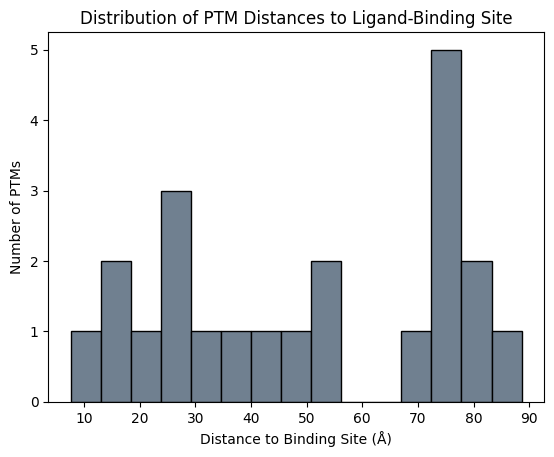

In [45]:
# Q1
close_ptms = ptm_mapped_df[ptm_mapped_df["DTPTM"] <= 10]
print(f"Number of PTMs within 10 Å of the binding site: {len(close_ptms)}")

# Q2
import matplotlib.pyplot as plt
plt.hist(ptm_mapped_df["DTPTM"], bins=15, color='slategray', edgecolor='black')
plt.xlabel("Distance to Binding Site (Å)")
plt.ylabel("Number of PTMs")
plt.title("Distribution of PTM Distances to Ligand-Binding Site")
plt.show()

### Exercise 2: Visual Inspection of Specific PTMs

**Instructions:**

1. Select one PTM that is **very close** (e.g., <10 Å) and another that is **very far** (>25 Å).
2. Use the `render_highconf_ptms()` viewer to visually compare their positions.
3. What regions of the protein do these PTMs lie in (e.g., folded domain vs. flexible tail)?
4. Do you think their position make them more likely to affect ligand binding?

### Exercise 3: Grouping PTMs by Type

**Instructions:**

1. Group PTMs by `type` (modification name).
2. For each type, calculate the average distance to the centroid.
3. Which PTM types tend to occur closer to the ligand-binding site?

In [46]:
ptm_summary = ptm_mapped_df.groupby("type")["DTPTM"].agg(["count", "mean", "min", "max"]).sort_values("mean")
ptm_summary

,count,mean,min,max
type,,,,
Phosphorylation,8,31.365435,7.557080,76.532809
Glutathionylation,4,43.970540,14.346834,88.648091
S-nitrosylation,2,46.546763,41.763089,51.330437
Ubiquitination,6,71.092702,50.105150,82.373249
Acetylation,1,76.027483,76.027483,76.027483
Malonylation,1,76.027483,76.027483,76.027483


### Exercise 4: Biological Interpretation

**Instructions (written/discussion):**

- PTMs often regulate protein activity, stability, or localization. 
- Based on the spatial locations of PTMs in KEAP1, which ones might: 
 - Affect ligand binding directly? 
 - Alter the shape of nearby binding pockets? 
 - Be more structural vs. regulatory in nature?

Write a short paragraph (3–5 sentences) interpreting one or two specific PTMs in KEAP1 using your visualization and DTM analysis.

This workflow was developed by Jonnathan Castro at the University of North Carolina at Chapel Hill.